# Notebook 4d — RF con CV por animal: Patrón de lesiones (3 clases) — **SOLO granja VC30D**
### Tuberculosis bovina

Target: **Patron_lesiones_3** — -1=sin lesión, 0=localizado, 1=generalizado.
Análisis restringido a los animales de la **explotación VC30D**.

> **Pregunta de investigación:** ¿pueden los biomarcadores discriminar los tres patrones
> lesionales *dentro de la explotación VC30D*?

**Comparar con:**
- *Notebook 2d*: cohorte completo sin Expl.
- *Notebook 3d*: cohorte completo con Expl.
- *Este notebook (4d)*: análisis intra-granja VC30D.

## 1. Setup e importaciones

In [1]:
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.model_selection import (RepeatedStratifiedKFold, StratifiedKFold)
from sklearn.metrics import (balanced_accuracy_score, roc_auc_score)
from sklearn.inspection import permutation_importance, PartialDependenceDisplay
import shap
import tb_utils as tb

PALETTE = tb.set_plot_style()
tb.set_seeds(tb.SEED)

GRANJA = "VC30D"

DATA = "../BD.csv"
df = tb.clean(tb.load_raw(DATA))

d = tb.target_subset(df, "Patron_lesiones_3")
d = d[d[tb.GROUP_COL] == GRANJA].copy().reset_index(drop=True)
d = tb.drop_sparse_rows(d)

X_all = d[tb.MODEL_FEATURES].copy()
y     = d["Patron_lesiones_3"].astype(int).values

print(f"Explotación: {GRANJA}")
print(f"Dataset: n={len(y)}")
print(f"Features ({len(tb.MODEL_FEATURES)}): {tb.MODEL_FEATURES}")
print("Distribución de clases:")
print(pd.Series(y).value_counts().sort_index())
print("Balanced acc. azar (3 clases) = 0.333")
print(f"\nNota: análisis intra-granja {GRANJA}. Sin confusor inter-granja.")

Explotación: VC30D
Dataset: n=55
Features (8): ['VITAMINA_D', 'CALCIO', 'PIROPLASMA_Q_log', 'EDAD', 'PIROPLASMA', 'THEILERIA', 'ANAPLASMA', 'RAZA2']
Distribución de clases:
-1    23
 0    24
 1     8
Name: count, dtype: int64
Balanced acc. azar (3 clases) = 0.333

Nota: análisis intra-granja VC30D. Sin confusor inter-granja.


## 2. Random Forest y estrategia de validación cruzada

**CV por animal en VC30D (RepeatedStratifiedKFold, 5×10):**
- Estratificado por `y` (3 clases).
- Con n reducido, la varianza del CV es mayor — interpretar con cautela.
- **Nota:** si alguna clase tiene muy pocos ejemplos en VC30D, el CV puede producir
  folds sin representación de todas las clases.

In [2]:
def make_rf(n_estimators=100, min_samples_leaf=3):
    return RandomForestClassifier(
        n_estimators=n_estimators,
        max_depth=None,
        min_samples_leaf=min_samples_leaf,
        max_features="sqrt",
        class_weight="balanced",
        random_state=tb.SEED,
        n_jobs=-1,
        oob_score=True,
    )

def make_pipe_4d(feature_list, n_estimators=100):
    num_f = [f for f in feature_list if f in tb.NUM_FEATURES]
    cat_f = [f for f in feature_list if f in tb.CAT_FEATURES]
    prep  = tb.make_preprocessor(numeric=num_f, categorical=cat_f, scale=False)
    return Pipeline([("prep", prep), ("clf", make_rf(n_estimators=n_estimators))])

CV_OUTER = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)

def cv_metrics_4d(feature_list, X, y, cv=None, detailed=False, n_estimators=100):
    if cv is None:
        cv = RepeatedStratifiedKFold(n_splits=5, n_repeats=10, random_state=tb.SEED)
    Xs = X[list(feature_list)]
    pipe_tmpl = make_pipe_4d(feature_list, n_estimators)
    rows = []
    for tr, te in cv.split(Xs, y):
        if len(np.unique(y[te])) < 2: continue
        pf = clone(pipe_tmpl)
        pf.fit(Xs.iloc[tr], y[tr])
        p    = pf.predict_proba(Xs.iloc[te])
        pred = pf.predict(Xs.iloc[te])
        bal  = balanced_accuracy_score(y[te], pred)
        try:
            roc = roc_auc_score(y[te], p, multi_class='ovr', average='macro')
        except Exception:
            roc = np.nan
        rows.append(dict(bal_acc=bal, roc_mac=roc))
    df_r = pd.DataFrame(rows)
    if detailed:
        return df_r
    return df_r.bal_acc.mean(), df_r.bal_acc.std()

print(f"Evaluación baseline RF ({GRANJA}):")
base_m, base_s = cv_metrics_4d(tb.MODEL_FEATURES, X_all, y)
print(f"  BAL_ACC = {base_m:.3f} ± {base_s:.3f}")
print(f"  Balanced acc. azar (3 clases) = 0.333")

Evaluación baseline RF (VC30D):
  BAL_ACC = 0.385 ± 0.147
  Balanced acc. azar (3 clases) = 0.333


## 3. Pipeline de selección de características

Paso 1: Ajustando RF completo en VC30D...
OOB Score: 0.382

Ranking importancia de permutación (VC30D):
                 pretty  imp_mean  imp_std
                 Calcio    0.2334   0.0515
     Anaplasma spp. (+)    0.2078   0.0592
             Vitamina D    0.1414   0.0419
log(1+Carga piroplasma)    0.1372   0.0366
            Edad (años)    0.1248   0.0357
                   Raza    0.0918   0.0310
     Theileria spp. (+)    0.0166   0.0222
         Piroplasma (+)    0.0000   0.0000


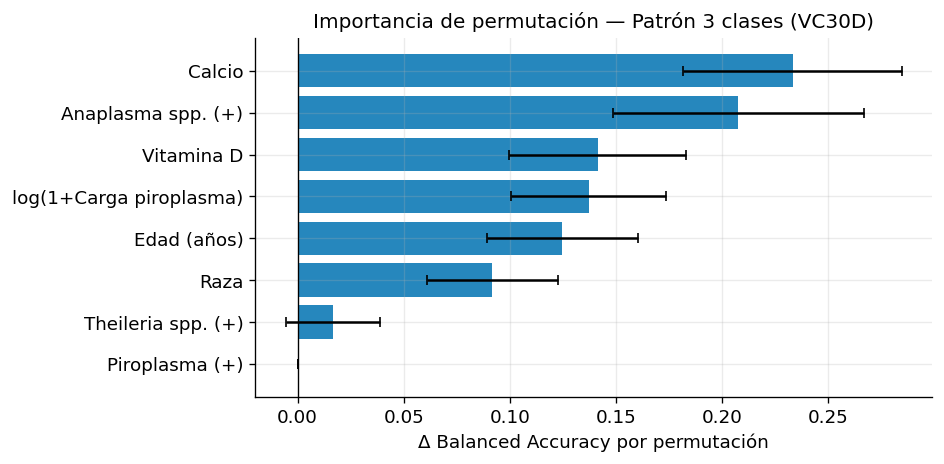

In [3]:
print(f"Paso 1: Ajustando RF completo en {GRANJA}...")
full_pipe = make_pipe_4d(tb.MODEL_FEATURES).fit(X_all, y)
print(f"OOB Score: {full_pipe.named_steps['clf'].oob_score_:.3f}")

pi = permutation_importance(
    full_pipe, X_all, y,
    scoring="balanced_accuracy",
    n_repeats=50,
    random_state=tb.SEED,
    n_jobs=-1,
)
imp_df = pd.DataFrame({
    "feature":  tb.MODEL_FEATURES,
    "imp_mean": pi.importances_mean,
    "imp_std":  pi.importances_std,
}).sort_values("imp_mean", ascending=False).reset_index(drop=True)
imp_df["pretty"] = imp_df.feature.map(lambda f: tb.PRETTY.get(f, f))

print(f"\nRanking importancia de permutación ({GRANJA}):")
print(imp_df[["pretty", "imp_mean", "imp_std"]].round(4).to_string(index=False))

fig, ax = plt.subplots(figsize=(8, 4))
order = imp_df.sort_values("imp_mean")
ax.barh(order.pretty, order.imp_mean, xerr=order.imp_std, color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación")
ax.set_title(f"Importancia de permutación — Patrón 3 clases ({GRANJA})")
plt.tight_layout(); plt.savefig("figures/fig_04d_perm_importance_full.png"); plt.show()

Orden de eliminación: ['PIROPLASMA', 'THEILERIA', 'RAZA2', 'EDAD', 'PIROPLASMA_Q_log', 'VITAMINA_D', 'ANAPLASMA', 'CALCIO']

   8 features [baseline] BAL_ACC=0.382±0.171
   7 features [-PIROPLASMA          ] BAL_ACC=0.416±0.175  Δ=+0.033
   6 features [-THEILERIA           ] BAL_ACC=0.388±0.187  Δ=+0.006
   5 features [-RAZA2               ] BAL_ACC=0.374±0.171  Δ=-0.008
   4 features [-EDAD                ] BAL_ACC=0.392±0.145  Δ=+0.010
   3 features [-PIROPLASMA_Q_log    ] BAL_ACC=0.504±0.184  Δ=+0.122
   2 features [-VITAMINA_D          ] BAL_ACC=0.506±0.151  Δ=+0.123
   1 features [-ANAPLASMA           ] BAL_ACC=0.379±0.139  Δ=-0.003


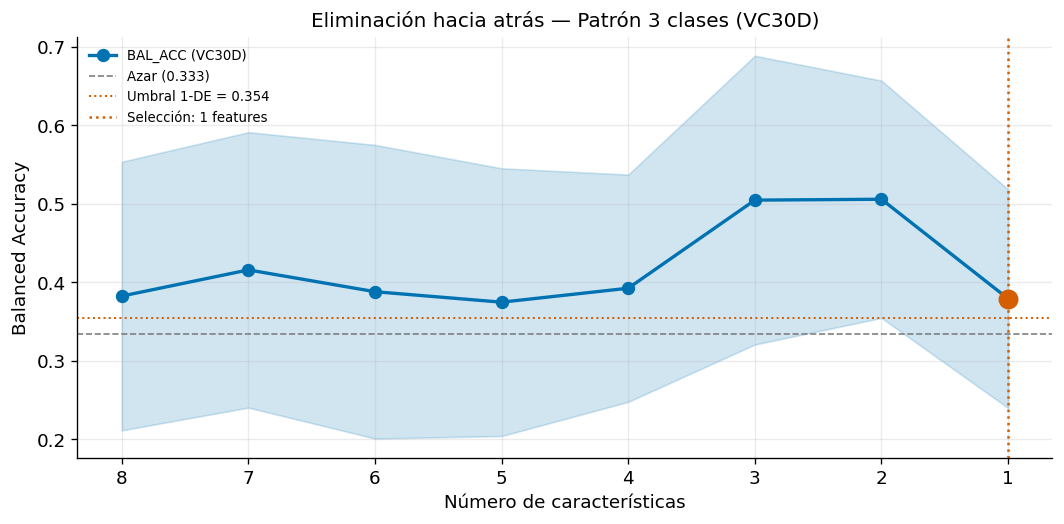


Features SELECCIONADOS (1): ['CALCIO']


In [4]:
CV_SEL = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=tb.SEED)
elim_order = imp_df.sort_values("imp_mean", ascending=True)["feature"].tolist()
print(f"Orden de eliminación: {elim_order}\n")

current_features = tb.MODEL_FEATURES.copy()
history = []

m0, s0 = cv_metrics_4d(current_features, X_all, y, cv=CV_SEL)
history.append({"n": len(current_features), "features": current_features.copy(),
                "removed": "—(baseline)", "mean": m0, "std": s0})
print(f"  {len(current_features):2d} features [baseline] BAL_ACC={m0:.3f}±{s0:.3f}")

for feat in elim_order:
    if feat not in current_features or len(current_features) <= 1: break
    test_feats = [f for f in current_features if f != feat]
    m, s = cv_metrics_4d(test_feats, X_all, y, cv=CV_SEL)
    history.append({"n": len(test_feats), "features": test_feats.copy(),
                    "removed": feat, "mean": m, "std": s})
    print(f"  {len(test_feats):2d} features [-{feat:20s}] BAL_ACC={m:.3f}±{s:.3f}  Δ={m-m0:+.3f}")
    current_features = test_feats

hist_df = pd.DataFrame(history)

best_idx     = hist_df["mean"].idxmax()
best_mu      = hist_df["mean"].max()
threshold    = best_mu - hist_df.loc[best_idx, "std"]
parsimonious = hist_df[hist_df["mean"] >= threshold].sort_values("n").iloc[0]
SELECTED_4D  = list(parsimonious.features)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.plot(hist_df.n, hist_df["mean"], "o-", color=PALETTE[0], lw=2, ms=7, label=f"BAL_ACC ({GRANJA})")
ax.fill_between(hist_df.n, hist_df["mean"]-hist_df["std"], hist_df["mean"]+hist_df["std"], alpha=0.18, color=PALETTE[0])
ax.axhline(1/3, ls="--", color="grey", lw=1, label="Azar (0.333)")
ax.axhline(threshold, ls=":", color=PALETTE[1], lw=1.2, label=f"Umbral 1-DE = {threshold:.3f}")
ax.axvline(parsimonious.n, color=PALETTE[1], ls=":", lw=1.5, label=f"Selección: {int(parsimonious.n)} features")
ax.scatter([parsimonious.n], [parsimonious["mean"]], color=PALETTE[1], s=120, zorder=5)
ax.set_xlabel("Número de características"); ax.set_ylabel("Balanced Accuracy")
ax.set_title(f"Eliminación hacia atrás — Patrón 3 clases ({GRANJA})")
ax.legend(fontsize=8); ax.invert_xaxis()
plt.tight_layout(); plt.savefig("figures/fig_04d_feature_selection_curve.png"); plt.show()
print(f"\nFeatures SELECCIONADOS ({len(SELECTED_4D)}): {SELECTED_4D}")

## 4. Evaluación del modelo final (CV por animal, 5×10)

Features seleccionados (3): ['CALCIO', 'ANAPLASMA', 'VITAMINA_D']



Métricas CV por animal (5×10, VC30D):
  BAL_ACC  = 0.508 ± 0.183   (azar = 0.333)
  ROC mac  = 0.660 ± 0.128   (azar = 0.5)


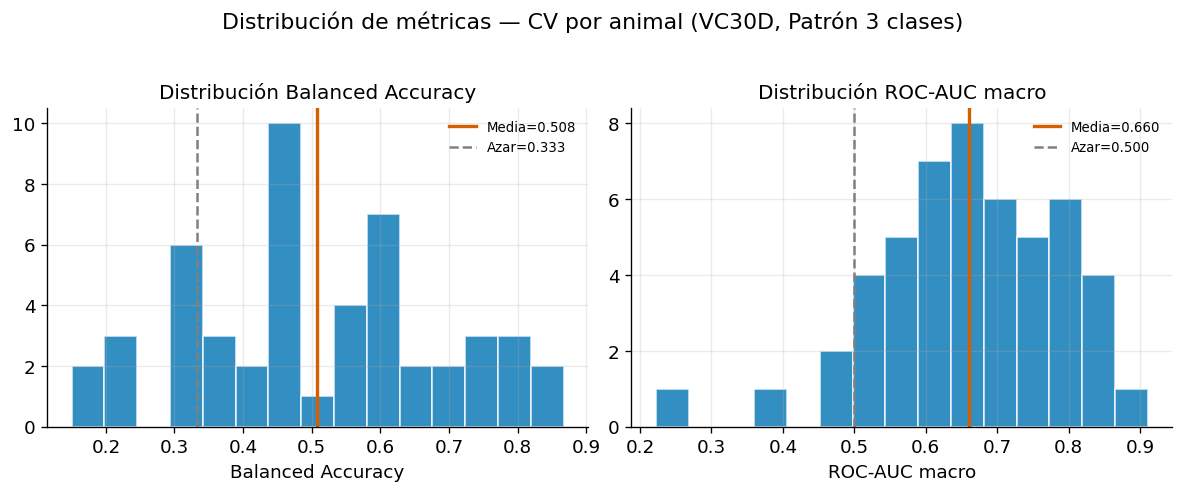

In [5]:
SELECTED_4D = ["CALCIO", "ANAPLASMA","VITAMINA_D"]
Xs = X_all[SELECTED_4D].copy()
print(f"Features seleccionados ({len(SELECTED_4D)}): {SELECTED_4D}\n")

detailed_df = cv_metrics_4d(SELECTED_4D, X_all, y, cv=CV_OUTER, detailed=True, n_estimators=700)
m = detailed_df.mean(); s = detailed_df.std()

print(f"Métricas CV por animal (5×10, {GRANJA}):")
print(f"  BAL_ACC  = {m.bal_acc:.3f} ± {s.bal_acc:.3f}   (azar = 0.333)")
print(f"  ROC mac  = {m.roc_mac:.3f} ± {s.roc_mac:.3f}   (azar = 0.5)")

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, col, title, chance in zip(axes, ["bal_acc", "roc_mac"],
                                   ["Balanced Accuracy", "ROC-AUC macro"], [1/3, 0.5]):
    ax.hist(detailed_df[col].dropna(), bins=15, color=PALETTE[0], alpha=0.8, edgecolor="white")
    ax.axvline(detailed_df[col].mean(), color=PALETTE[1], lw=2,
               label=f"Media={detailed_df[col].mean():.3f}")
    ax.axvline(chance, color="grey", ls="--", lw=1.5, label=f"Azar={chance:.3f}")
    ax.set_xlabel(title); ax.set_title(f"Distribución {title}"); ax.legend(fontsize=8)
plt.suptitle(f"Distribución de métricas — CV por animal ({GRANJA}, Patrón 3 clases)", y=1.02)
plt.tight_layout(); plt.savefig("figures/fig_04d_metrics_dist.png", bbox_inches="tight"); plt.show()

## 5. Interpretabilidad global — SHAP

OOB Score: 0.473
Features: ['CALCIO', 'ANAPLASMA', 'VITAMINA_D']  |  Clases: [-1  0  1]  |  idx_gen: 2


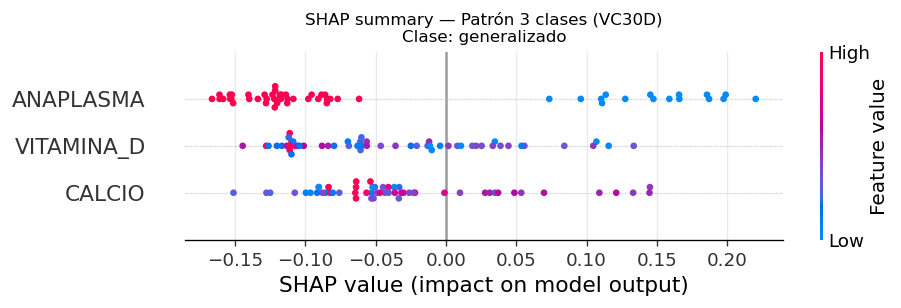

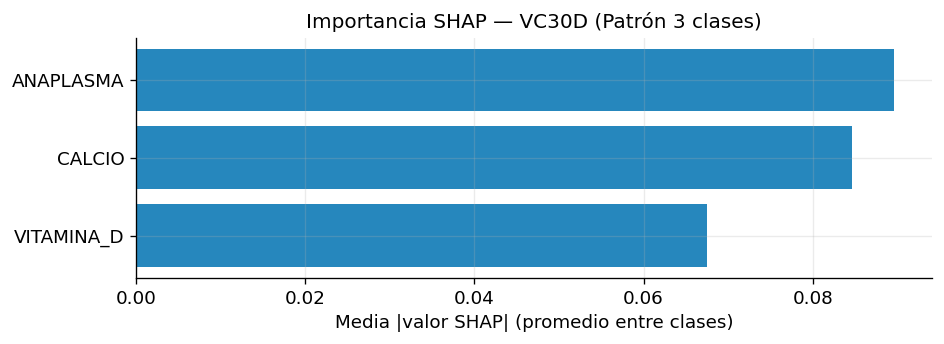

In [6]:
FINAL_4D = make_pipe_4d(SELECTED_4D, n_estimators=500).fit(Xs, y)
print(f"OOB Score: {FINAL_4D.named_steps['clf'].oob_score_:.3f}")

prep_4d  = FINAL_4D.named_steps["prep"]
clf_4d   = FINAL_4D.named_steps["clf"]
Xt_4d    = prep_4d.transform(Xs)
names_4d = list(prep_4d.get_feature_names_out())

explainer_4d = shap.TreeExplainer(clf_4d)
shap_vals_4d = explainer_4d.shap_values(Xt_4d)

if isinstance(shap_vals_4d, list):
    sv_d_list = shap_vals_4d
    sv_d_mean = np.mean([np.abs(s) for s in sv_d_list], axis=0)
else:
    arr = np.asarray(shap_vals_4d)
    if arr.ndim == 3:
        sv_d_list = [arr[:, :, i] for i in range(arr.shape[2])]
        sv_d_mean = np.abs(arr).mean(axis=2)
    else:
        sv_d_list = [arr]; sv_d_mean = np.abs(arr)

classes_sorted = np.sort(np.unique(y))
idx_gen = np.where(classes_sorted == 1)[0][0] if 1 in classes_sorted else -1
if idx_gen >= 0:
    sv_d_gen = sv_d_list[idx_gen]
    exp_val_4d = (float(explainer_4d.expected_value[idx_gen])
                  if isinstance(explainer_4d.expected_value, (list, np.ndarray))
                  else float(explainer_4d.expected_value))
else:
    sv_d_gen = sv_d_list[0]; exp_val_4d = float(explainer_4d.expected_value[0])

print(f"Features: {names_4d}  |  Clases: {classes_sorted}  |  idx_gen: {idx_gen}")

plt.figure(figsize=(9, max(4, 0.5 * len(names_4d))))
shap.summary_plot(sv_d_gen, Xt_4d, feature_names=names_4d, show=False, max_display=len(names_4d))
plt.title(f"SHAP summary — Patrón 3 clases ({GRANJA})\nClase: generalizado", fontsize=10)
plt.tight_layout(); plt.savefig("figures/fig_04d_shap_summary.png", bbox_inches="tight"); plt.show()

mean_abs_4d = sv_d_mean.mean(0)
si_4d = pd.DataFrame({"feature": names_4d, "mean_abs": mean_abs_4d}).sort_values("mean_abs")
fig, ax = plt.subplots(figsize=(8, max(3, 0.4 * len(names_4d))))
ax.barh(si_4d.feature, si_4d.mean_abs, color=PALETTE[0], alpha=0.85)
ax.set_xlabel("Media |valor SHAP| (promedio entre clases)")
ax.set_title(f"Importancia SHAP — {GRANJA} (Patrón 3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_04d_shap_importance.png"); plt.show()

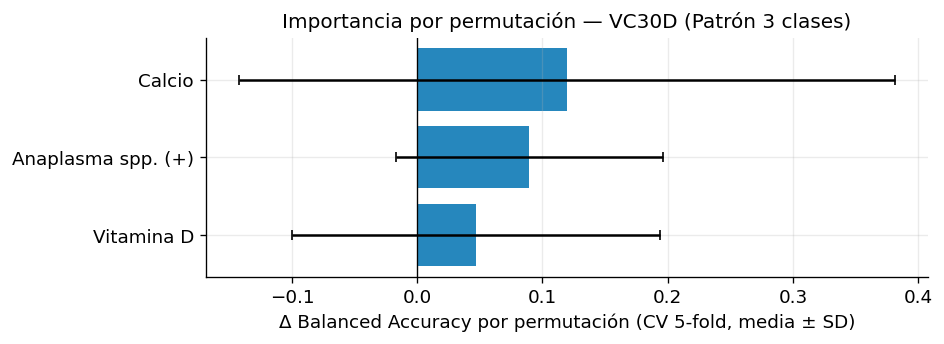

Estabilidad Spearman entre folds: -0.200


In [7]:
from scipy.stats import spearmanr
imp_runs_4d = []
cv_stab = StratifiedKFold(n_splits=5, shuffle=True, random_state=tb.SEED)
for tr, te in cv_stab.split(Xs, y):
    if len(np.unique(y[te])) < 2: continue
    pf = clone(make_pipe_4d(SELECTED_4D)).fit(Xs.iloc[tr], y[tr])
    pi_f = permutation_importance(pf, Xs.iloc[te], y[te],
                                  scoring="balanced_accuracy", n_repeats=20,
                                  random_state=tb.SEED)
    imp_runs_4d.append(pd.Series(pi_f.importances_mean, index=SELECTED_4D))

imp_mat_4d = pd.concat(imp_runs_4d, axis=1)
imp_ord_4d = imp_mat_4d.mean(axis=1).sort_values().index
R = imp_mat_4d.fillna(0)
cors = [spearmanr(R.iloc[:,i], R.iloc[:,j]).correlation
        for i in range(R.shape[1]) for j in range(i+1, R.shape[1])]

fig, ax = plt.subplots(figsize=(8, max(3, 0.45 * len(SELECTED_4D))))
ax.barh([tb.PRETTY.get(f, f) for f in imp_ord_4d],
        imp_mat_4d.mean(axis=1)[imp_ord_4d],
        xerr=imp_mat_4d.std(axis=1)[imp_ord_4d],
        color=PALETTE[0], capsize=3, alpha=0.85)
ax.axvline(0, color="k", lw=0.8)
ax.set_xlabel("Δ Balanced Accuracy por permutación (CV 5-fold, media ± SD)")
ax.set_title(f"Importancia por permutación — {GRANJA} (Patrón 3 clases)")
plt.tight_layout(); plt.savefig("figures/fig_04d_perm_importance_cv.png"); plt.show()
print(f"Estabilidad Spearman entre folds: {np.nanmean(cors):.3f}")

## 6. Partial Dependence Plots + ICE

Features continuas para PDP/ICE: ['CALCIO', 'VITAMINA_D']


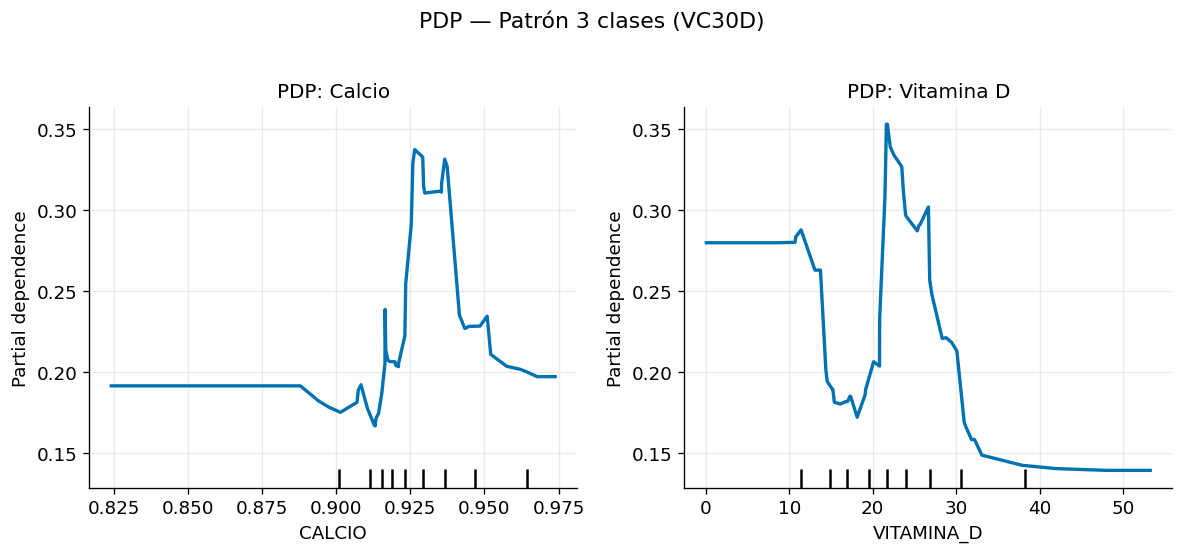

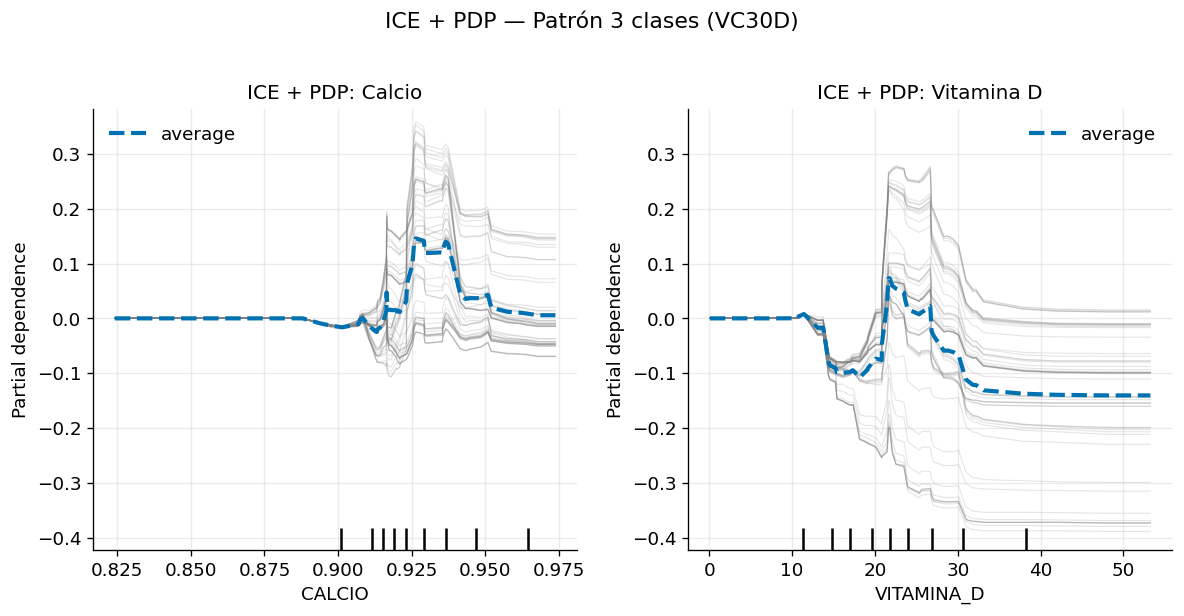

In [8]:
CONT_4D = [f for f in SELECTED_4D if f in tb.NUM_FEATURES and Xs[f].nunique() > 5]
if not CONT_4D:
    CONT_4D = [f for f in SELECTED_4D if f in tb.NUM_FEATURES]

target_label = int(classes_sorted[idx_gen]) if idx_gen >= 0 else int(classes_sorted[0])
target_col   = idx_gen if idx_gen >= 0 else 0  # columna en predict_proba
print(f"Features continuas para PDP/ICE: {CONT_4D}")
if CONT_4D:
    n_c = len(CONT_4D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4D, Xs, CONT_4D, kind="average",
        target=target_label, ax=axes, line_kw={"color": PALETTE[0], "lw": 2})
    for ax, f in zip(axes, CONT_4D):
        ax.set_title(f"PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"PDP — Patrón 3 clases ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04d_pdp.png", bbox_inches="tight"); plt.show()

    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 5))
    if n_c == 1: axes = [axes]
    PartialDependenceDisplay.from_estimator(FINAL_4D, Xs, CONT_4D, kind="both",
        target=target_label, ax=axes,
        ice_lines_kw={"color": "grey", "alpha": 0.2, "lw": 0.7},
        pd_line_kw={"color": PALETTE[0], "lw": 2.5},
        centered=True)
    for ax, f in zip(axes, CONT_4D):
        ax.set_title(f"ICE + PDP: {tb.PRETTY.get(f, f)}")
    plt.suptitle(f"ICE + PDP — Patrón 3 clases ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04d_ice.png", bbox_inches="tight"); plt.show()

## 7. ALE + Waterfall + Contrafactuales

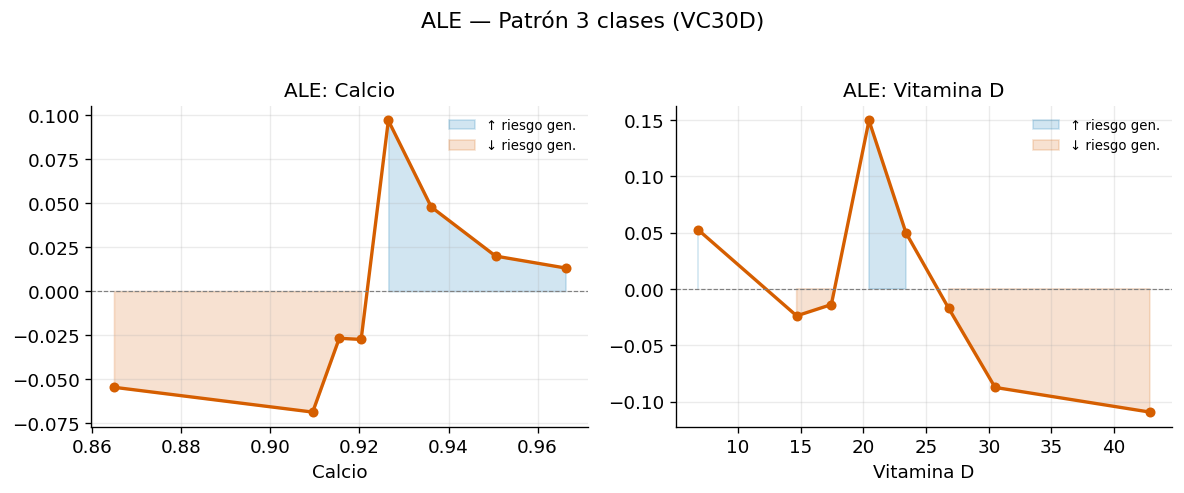

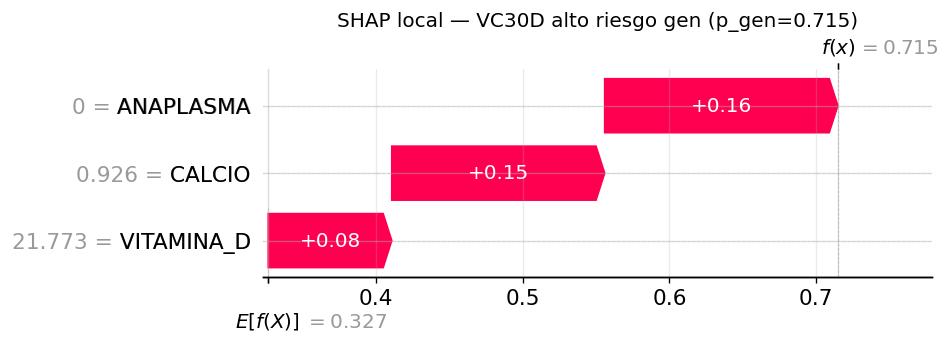

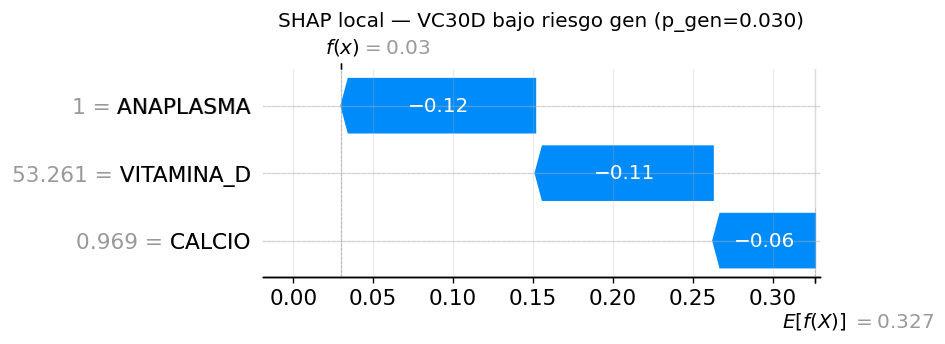

In [9]:
def ale_1d(model, X, feat, bins=8):
    x = X[feat].dropna().values
    q = np.quantile(x, np.linspace(0, 1, bins + 1)); q = np.unique(q)
    if len(q) < 3: return np.array([]), np.array([])
    eff, Xc = [], X.copy()
    for i in range(len(q) - 1):
        mask = (X[feat] >= q[i]) & (X[feat] <= q[i + 1])
        if mask.sum() == 0: eff.append(0.0); continue
        lo = Xc.loc[mask].copy(); lo[feat] = q[i]
        hi = Xc.loc[mask].copy(); hi[feat] = q[i + 1]
        eff.append((model.predict_proba(hi)[:, target_col] - model.predict_proba(lo)[:, target_col]).mean())
    ale = np.cumsum(eff); ale -= ale.mean()
    return (q[:-1] + q[1:]) / 2, ale

if CONT_4D:
    n_c = len(CONT_4D)
    fig, axes = plt.subplots(1, n_c, figsize=(5 * n_c, 4))
    if n_c == 1: axes = [axes]
    for ax, feat in zip(axes, CONT_4D):
        cx, ale = ale_1d(FINAL_4D, Xs, feat)
        if len(cx) == 0: ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}\n(insuf.)"); continue
        ax.plot(cx, ale, "o-", color=PALETTE[1], lw=2, ms=5)
        ax.axhline(0, color="grey", lw=0.7, ls="--")
        ax.fill_between(cx, 0, ale, where=(ale > 0), alpha=0.18, color=PALETTE[0], label="↑ riesgo gen.")
        ax.fill_between(cx, 0, ale, where=(ale < 0), alpha=0.18, color=PALETTE[1], label="↓ riesgo gen.")
        ax.set_title(f"ALE: {tb.PRETTY.get(feat,feat)}")
        ax.set_xlabel(tb.PRETTY.get(feat,feat)); ax.legend(fontsize=8)
    plt.suptitle(f"ALE — Patrón 3 clases ({GRANJA})", y=1.02)
    plt.tight_layout(); plt.savefig("figures/fig_04d_ale.png", bbox_inches="tight"); plt.show()

# SHAP waterfall
p_gen = FINAL_4D.predict_proba(Xs)[:, target_col]
idx_pos = int(np.argmax(p_gen)); idx_neg = int(np.argmin(p_gen))
shap_exp_4d = shap.Explanation(values=sv_d_gen, base_values=exp_val_4d, data=Xt_4d, feature_names=names_4d)

for tag, idx in [("alto_riesgo_gen", idx_pos), ("bajo_riesgo_gen", idx_neg)]:
    fig, _ = plt.subplots(figsize=(9, 4))
    shap.plots.waterfall(shap_exp_4d[idx], max_display=len(names_4d), show=False)
    plt.title(f"SHAP local — {GRANJA} {tag.replace('_',' ')} (p_gen={p_gen[idx]:.3f})")
    plt.tight_layout()
    plt.savefig(f"figures/fig_04d_waterfall_{tag}.png", bbox_inches="tight"); plt.show()

CONTRAFACTUALES — VC30D  (Patrón 3 clases)

Generalizado → Localizado
  actual=Generalizado, probs: [Sin lesión=0.07 | Localizado=0.21 | Generalizado=0.71]
  Calcio                        : actual=0.93 → cf=0.91  (Δ=-0.02)
  Vitamina D                    : no alcanzable en [0.08, 53.26]

Generalizado → Sin lesión
  actual=Generalizado, probs: [Sin lesión=0.07 | Localizado=0.21 | Generalizado=0.71]
  Calcio                        : no alcanzable en [0.82, 0.97]
  Vitamina D                    : no alcanzable en [0.08, 53.26]

Sin lesión   → Localizado
  actual=Sin lesión, probs: [Sin lesión=0.69 | Localizado=0.23 | Generalizado=0.08]
  Calcio                        : no alcanzable en [0.82, 0.97]
  Vitamina D                    : no alcanzable en [0.08, 53.26]


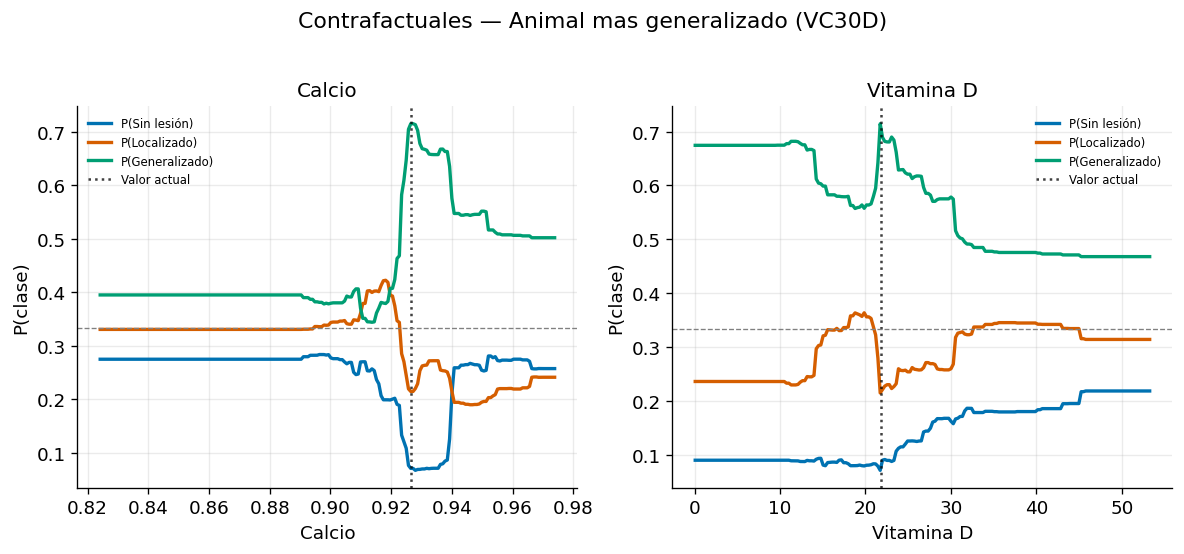

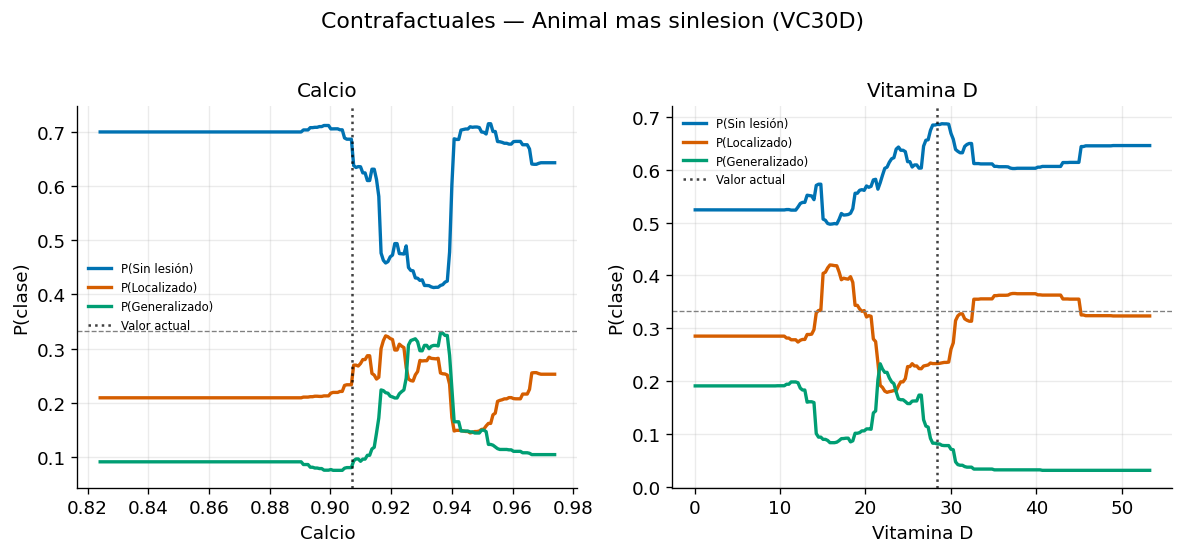

In [10]:
# Contrafactuales multiclase: qué cambio en una variable continua bastaría
# para que el modelo prediga una clase diferente.

def find_cf_multiclass(model, row_dict, feat, lo_v, hi_v, target_cls, n=500):
    """Primer valor de feat en [lo_v, hi_v] que hace predict == target_cls."""
    for v in np.linspace(lo_v, hi_v, n):
        r = dict(row_dict); r[feat] = v
        if int(model.predict(pd.DataFrame([r]))[0]) == target_cls:
            return v
    return None

p_proba_all    = FINAL_4D.predict_proba(Xs)
idx_gen_animal = int(np.argmax(p_proba_all[:, target_col]))  # más probable generalizado
idx_neg_animal = int(np.argmax(p_proba_all[:, 0]))           # más probable sin lesión (col 0)

class_names = {int(c): lb
               for c, lb in zip(classes_sorted,
                                 ["Sin lesión", "Localizado", "Generalizado"])}

print("=" * 65)
print(f"CONTRAFACTUALES — {GRANJA}  (Patrón 3 clases)")
print("=" * 65)
for tag, row_idx, target_cf in [
    ("Generalizado → Localizado",  idx_gen_animal,  0),
    ("Generalizado → Sin lesión",  idx_gen_animal, -1),
    ("Sin lesión   → Localizado",  idx_neg_animal,  0),
]:
    row     = Xs.iloc[row_idx]
    pred_cur = int(FINAL_4D.predict(pd.DataFrame([row]))[0])
    p_cur    = FINAL_4D.predict_proba(pd.DataFrame([row]))[0]
    p_str    = " | ".join(
        f"{class_names.get(int(c), str(c))}={p:.2f}"
        for c, p in zip(classes_sorted, p_cur)
    )
    print(f"\n{tag}")
    print(f"  actual={class_names.get(pred_cur, pred_cur)}, probs: [{p_str}]")
    if not CONT_4D:
        print("  (sin features continuas en el subconjunto seleccionado)")
        continue
    for feat in CONT_4D:
        lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
        cf_val = find_cf_multiclass(FINAL_4D, row.to_dict(), feat, lo_v, hi_v, target_cf)
        cur_val = float(row[feat])
        if cf_val is not None:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: "
                  f"actual={cur_val:.2f} → cf={cf_val:.2f}  (Δ={cf_val - cur_val:+.2f})")
        else:
            print(f"  {tb.PRETTY.get(feat, feat):30s}: "
                  f"no alcanzable en [{lo_v:.2f}, {hi_v:.2f}]")

# ── Curvas P(clase) vs feature (una figura por animal representativo) ──
if CONT_4D:
    col_colors = [PALETTE[i % len(PALETTE)] for i in range(len(classes_sorted))]

    for tag, row_idx in [
        ("animal_mas_generalizado", idx_gen_animal),
        ("animal_mas_sinlesion",    idx_neg_animal),
    ]:
        row = Xs.iloc[row_idx]
        n_c = len(CONT_4D)
        fig, axes_cf = plt.subplots(1, n_c, figsize=(5 * n_c, 4.5))
        if n_c == 1:
            axes_cf = [axes_cf]
        for ax, feat in zip(axes_cf, CONT_4D):
            lo_v, hi_v = float(Xs[feat].min()), float(Xs[feat].max())
            grid = np.linspace(lo_v, hi_v, 200)
            for ci, cls in enumerate(classes_sorted):
                probs = [
                    FINAL_4D.predict_proba(
                        pd.DataFrame([{**row.to_dict(), feat: v}])
                    )[0, ci]
                    for v in grid
                ]
                ax.plot(grid, probs, color=col_colors[ci], lw=2,
                        label=f"P({class_names.get(int(cls), str(cls))})")
            ax.axvline(float(row[feat]), color="black", ls=":", lw=1.5,
                       alpha=0.75, label="Valor actual")
            ax.axhline(1 / 3, color="grey", ls="--", lw=0.8)
            ax.set_xlabel(tb.PRETTY.get(feat, feat))
            ax.set_ylabel("P(clase)")
            ax.set_title(tb.PRETTY.get(feat, feat))
            ax.legend(fontsize=7)
        title = tag.replace("_", " ").capitalize()
        plt.suptitle(f"Contrafactuales — {title} ({GRANJA})", y=1.02)
        plt.tight_layout()
        plt.savefig(f"figures/fig_04d_cf_{tag}.png", bbox_inches="tight")
        plt.show()


## 8. Síntesis

### Tabla comparativa

| Métrica | Nb 2d — completo sin expl | Nb 3d — completo + Expl | **Nb 4d — VC30D intra-granja** |
|---|---|---|---|
| BAL_ACC | — | — | **—** |
| ROC-AUC macro | — | — | **—** |
| n animales | ~103 | ~103 | **solo VC30D** |

**Precaución:** n reducido y 3 clases → folds con representación mínima por clase.
Los resultados son exploratorios. El BAL_ACC puede tener varianza muy alta.